# 模块六：无监督学习
**案例背景**：聚类与降维。本 Notebook 涵盖 K-Means 聚类和 PCA 降维。

# 无监督学习（Unsupervised）

本笔记本合并了该主题下的多个小实验，按小节依次编排。



---

## K-Means



来源: 面经知识库 04-unsupervised-learning.md §1.4 K-Means


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs



## 1. 模拟生成 3 个簇的数据


In [2]:
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)



## 2. 模型训练


In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
kmeans.fit(X)

y_kmeans = kmeans.predict(X)
centers = kmeans.cluster_centers_



## 3. 可视化


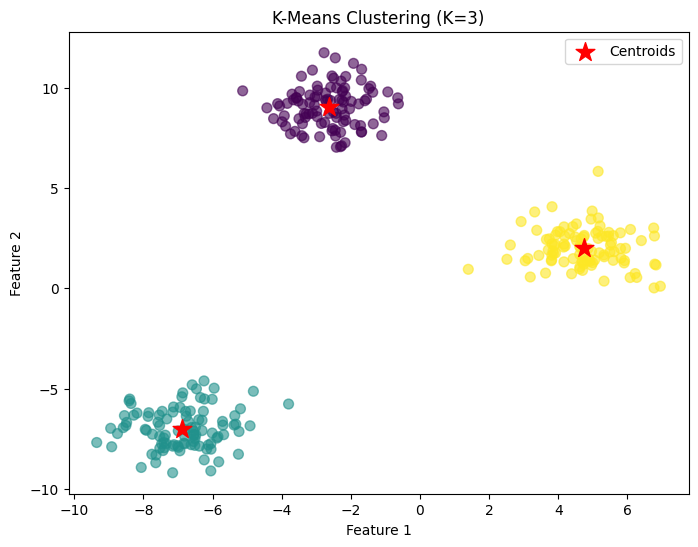

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap="viridis", alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="*", label="Centroids")

plt.title("K-Means Clustering (K=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


---

## PCA



来源: 面经知识库 04-unsupervised-learning.md §2.4 PCA


In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



## 1. 模拟生成三维数据


In [6]:
np.random.seed(42)
n_samples = 200
x1 = np.random.normal(0, 10, n_samples)
x2 = x1 * 0.8 + np.random.normal(0, 2, n_samples)
x3 = np.random.normal(0, 5, n_samples)

X = np.column_stack((x1, x2, x3))



## 2. 数据标准化 (PCA 必须步骤)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## 3. PCA 模型训练与降维


In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("--- PCA 降维结果 ---")
print(f"各主成分的方差贡献率: {pca.explained_variance_ratio_}")
print(f"累积方差贡献率: {np.sum(pca.explained_variance_ratio_):.2f}")



--- PCA 降维结果 ---
各主成分的方差贡献率: [0.66816636 0.32131559]
累积方差贡献率: 0.99


## 5. 可视化降维后的二维数据


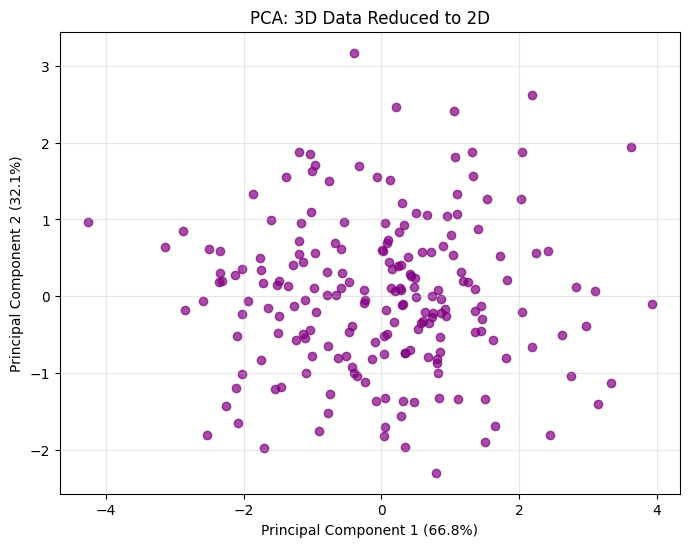

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, color="purple")
plt.title("PCA: 3D Data Reduced to 2D")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, alpha=0.3)
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()
